# Trabajo Práctico N°7 del TPS: PCA, K-means y EM

En este trabajo práctico se implementa un algoritmo de PCA condicional para aprender una curva representativa de un *manifold* 2D no lineal. La idea es combinar un algoritmo de clustering (K-Means y luego EM) con un PCA por cluster, de manera que cada cluster aproxime localmente una recta del manifold. Finalmente, se utiliza el error de reconstrucción del PCA como detector de anomalías.



Se importan las librerías que se utilizarán a lo largo del mismo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Inciso A: Creación del *dataset*



El objetivo de este inciso es generar datos sintéticos que simulen mediciones ruidosas de una curva en el plano. La curva subyacente (el manifold) es un triángulo formado por tres segmentos de recta, definido por la función $g(u)$ para $u \in [0, 1]$.

La curva subyacente se llama manifold: es una curva parametrizada $g(u)$ con $u \in [0,1]$, exactamente igual a las parametrizaciones de Análisis II. Con un solo parámetro $u$ se puede ubicar cualquier punto de la curva, aunque esa curva viva en $\mathbb{R}^2$. En este caso, $g(u)$ traza un triángulo, sube en diagonal, baja en diagonal, y vuelve horizontalmente al origen.

Para generar los datos se realiza una simulación de Monte Carlo con dos fuentes de aleatoriedad:
- $U_i \sim \mathcal{U}(0,1)$: elige un punto al azar a lo largo de la curva.
- $Z_i \sim \mathcal{N}(0, I)$: agrega ruido gaussiano en todas las direcciones, simulando error de medición.

El resultado es una nube de 200 puntos distribuidos cerca del triángulo. El objetivo de todo el TP es que los algoritmos recuperen ese triángulo a partir de los datos, sin saber de antemano que es un triángulo.

In [2]:
np.random.seed(42)

N = 200

# Sortear U_i ~ Uniform(0,1)
U = np.random.uniform(0, 1, N)

# Evaluar g(u) — tres tramos lineales
def g(u):
    x = np.where(u < 1/3,  1.5 * u,
        np.where(u < 2/3,  1.5 * u,
                            3 - 3 * u))
    y = np.where(u < 1/3,  3 * u,
        np.where(u < 2/3,  2 - 3 * u,
                            np.zeros_like(u)))
    return np.column_stack([x, y])

G = g(U)

# Ruido gaussiano estándar bivariado
Z = np.random.randn(N, 2)

X = G + 0.05 * Z

Se grafica el *scatter* y el *mainfold* en el mismo plano.

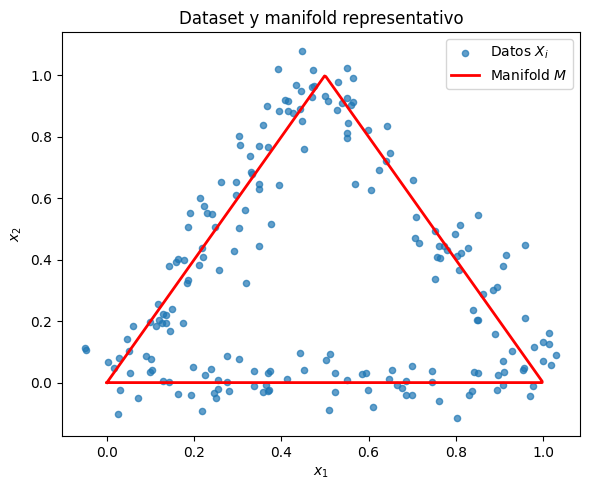

In [3]:
# Curva representativa del manifold (sin ruido)
u_curve = np.linspace(0, 1, 500)
M = g(u_curve)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7, label='Datos $X_i$')
ax.plot(M[:, 0], M[:, 1], color='red', linewidth=2, label='Manifold $M$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Dataset y manifold representativo')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico muestra lo esperado: los 200 puntos forman tres nubes alargadas, una por cada lado del triángulo, y la curva roja pasa por el centro de cada nube. El ruido es pequeño pero visible. Hay dispersión perpendicular a cada lado, simulando correctamente el error de medición.

A partir de esta visualización se puede anticipar el comportamiento de los algoritmos de clustering:

- **K-Means:** agrupa por distancia al centroide, asumiendo clusters circulares (isótropos). Esto puede ser problemático acá porque los tres grupos son claramente alargados y orientados en distintas direcciones. En las esquinas del triángulo, donde se juntan puntos de dos lados distintos, K-Means puede cometer errores de asignación.
- **EM:** modela cada cluster con una Gaussiana completa (con covarianza), por lo que puede capturar la forma alargada de cada lado. Se espera que encuentre los tres grupos con mayor precisión.

## Inciso B: K-Means

Se implementa el algoritmo K-Means para clusterizar los datos. El primer paso es elegir $K$, la cantidad de clusters.

En la práctica, $K$ no se conoce de antemano. Las estrategias habituales son probar varios valores y usar métricas como el método del codo -**ver que onda eso**- (graficar la inercia en función de $K$ y buscar el punto donde la mejora se vuelve marginal) o el silhouette score (qué tan bien separado está cada punto de los clusters vecinos). Es análogo a elegir el orden de un filtro en telecomunicaciones: probás distintos órdenes y buscás el punto donde agregar más no mejora significativamente la respuesta.

En este caso se usa conocimiento del dominio: el manifold tiene 3 lados, por lo que $K = 3$ es la elección natural. En telecomunicaciones sería como saber de antemano cuántas fuentes de señal hay. Cada cluster debería capturar un lado del triángulo.

### Implementación

La clase `KMeans` se construye con la misma estructura que en el TP6: inicialización aleatoria de centroides, reasignación por distancia euclidiana y actualización iterativa hasta convergencia.

Los hiperparámetros son:
- `max_iter=300`: cota de seguridad para que el algoritmo no corra indefinidamente si no converge. En la práctica K-Means converge en pocas iteraciones para datasets chicos.
- `tol=1e-4`: el algoritmo se detiene cuando el desplazamiento de los centroides entre iteraciones es menor a este umbral. Es el criterio de convergencia.

In [7]:
class KMeans:
    def __init__(self, k=3, max_iter=300, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.n_iter_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(len(X), self.k, replace=False)
        self.centroids = X[idx].astype(float).copy()

        for it in range(self.max_iter):
            labels = self._assign(X)

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j)
                else self.centroids[j]
                for j in range(self.k)
            ])

            shift = np.max(np.linalg.norm(new_centroids - self.centroids, axis=1))
            self.centroids = new_centroids

            if shift < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (shift = {shift:.2e})')
                break
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def _assign(self, X):
        dists = np.linalg.norm(X[:, None, :] - self.centroids[None, :, :], axis=2)
        return np.argmin(dists, axis=1)

    def predict(self, X):
        return self._assign(X)

### Entrenamiento y visualización

Convergió en 5 iteraciones (shift = 0.00e+00)


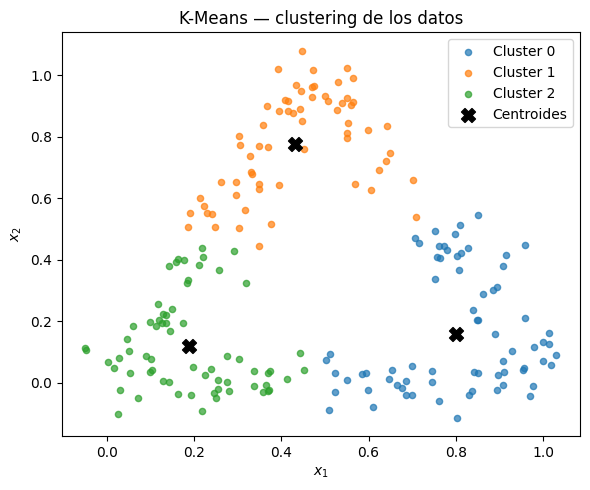

In [8]:
km = KMeans(k=3)
km.fit(X)
labels_km = km.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(km.k):
    mask = labels_km == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], s=100, marker='X', color='black', zorder=5, label='Centroides')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('K-Means — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

El algoritmo convergió en solo **5 iteraciones**, lo que confirma que para un dataset pequeño y bien separado como este, K-Means es muy rápido.

Mirando el gráfico, los tres clusters recuperan aproximadamente los tres lados del triángulo. Sin embargo, se pueden observar problemas en las **esquinas**: algunos puntos que pertenecen a un lado quedan asignados al cluster del lado adyacente. Esto es consecuencia directa de que K-Means asigna cada punto al centroide más cercano en distancia euclidiana, asumiendo implícitamente que los clusters son **esféricos e isótropos**. Los lados del triángulo son estructuras alargadas y orientadas, no círculos — por lo tanto K-Means no es el modelo adecuado para esta geometría.

### ¿Es suficiente K-Means para esta tarea?

**No.** K-Means agrupa por proximidad al centroide sin considerar la orientación ni la forma de los clusters. En las esquinas del triángulo, un punto puede estar más cerca del centroide del lado adyacente que del centroide de su propio lado, simplemente porque los centroides quedan en el medio de cada lado. Esto genera errores de asignación sistemáticos en las zonas de transición entre segmentos.

Para capturar correctamente la geometría alargada de cada lado se necesita un modelo que modele también la **covarianza** de cada cluster — es decir, el algoritmo EM con mezclas de Gaussianas.